In [ ]:
! pip install wikipedia

import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd

In [ ]:

!pip install wikipedia
import wikipedia
import pandas as pd
topics = ["Giraffe", "Elephant"]
def get_wiki_content(topic, lang="en"):
    wikipedia.set_lang(lang)
    try:
        return wikipedia.page(topic, auto_suggest=False).content
    except wikipedia.exceptions.DisambiguationError as e:

        return wikipedia.page(e.options[0], auto_suggest=False).content
    except wikipedia.exceptions.PageError:

        return f"Page not found for {topic} in {lang}"
data = []
for topic in topics:
    eng_text = get_wiki_content(topic, lang="en")
    fr_text = get_wiki_content(topic, lang="fr")
    data.append({"Topic": topic, "English": eng_text, "French": fr_text})
df = pd.DataFrame(data)
df.to_csv("wiki_topics.csv", index=False)
for i, row in df.iterrows():
    print(f"--- {row['Topic']} ---")
    print("English:", row['English'][:300], "...\n")
    print("French:", row['French'][:300], "...\n")

ERROR-DisambiguationError from wikipedia.page()

ERROR-PageError

Problem: If the topic does not exist on Wikipedia, it raises:

ERROR-Language switching issues

ERRORauto_suggest

By default, wikipedia.page() auto-suggests similar pages, which may fetch the wrong page.

Fix: Set auto_suggest=False to get the exact page.

SYNTAX ERROR


Large output issues

In [ ]:

!pip install wikipedia
import wikipedia
import pandas as pd


def cleanup(text):
    """Remove newlines, extra spaces, and non-ASCII characters"""
    text = text.replace("\n", " ").replace("\r", " ")
    text = " ".join(text.split())
    text = text.encode("ascii", errors="ignore").decode()  # optional for English
    return text


topics = ["Giraffe", "Elephant"]

def get_wiki_content(topic, lang="en"):
    wikipedia.set_lang(lang)
    try:
        content = wikipedia.page(topic, auto_suggest=False).content
    except wikipedia.exceptions.DisambiguationError as e:

        content = wikipedia.page(e.options[0], auto_suggest=False).content
    except wikipedia.exceptions.PageError:
        content = f"Page not found for {topic} in {lang}"
    return cleanup(content)

data = []
for topic in topics:
    eng_text = get_wiki_content(topic, lang="en")
    fr_text = get_wiki_content(topic, lang="fr")
    data.append({"Topic": topic, "English": eng_text, "French": fr_text})


df = pd.DataFrame(data)

df.to_csv("wiki_topics.csv", index=False)


for i, row in df.iterrows():
    print(f"--- {row['Topic']} ---")
    print("English:", row['English'][:300], "...\n")
    print("French:", row['French'][:300], "...\n")

ERROR-DisambiguationError

Problem: Some topics like “Elephant” or “Giraffe” have multiple pages on Wikipedia (disambiguation pages).

Your code just calls wikipedia.page(topic1), so Python throws:

PageError

Problem: If a topic does not exist in the chosen language (e.g., French Wikipedia may not have the exact topic), it raises:

auto_suggest default behavior

Problem: By default, wikipedia.page() auto-suggests similar pages, which may not be the page you want.

Example: Giraffe might fetch a suggestion like “Giraffes in popular culture”.

Fix: Use auto_suggest=False to fetch the exact topic.

In [ ]:

!pip install nltk matplotlib

import matplotlib.pyplot as plt
from nltk.util import ngrams
from collections import Counter

eng1 = "giraffe is a tall animal found in africa"
eng2 = "elephant is the largest land animal"

def plothistogram(ngram):
    keys = [' '.join(i) for i in ngram.keys()]
    values = list(ngram.values())

    plt.bar(keys, values)
unigram_eng1 = Counter(ngrams(eng1.split(),1))
plothistogram(unigram_eng1)
plt.title('English 1')
plt.show()


unigram_eng2 = Counter(ngrams(eng2.split(),1))
plothistogram(unigram_eng2)
plt.title('English 2')
plt.show()

ERROR-NameError: ngrams is not defined
unigram_eng1 = Counter(ngrams(eng1,1))

ERROR-NameError: Counter is not defined
from collections import Counter
NameError: plothistogram is not defined
plothistogram(unigram_eng1)

In [ ]:
# Install library (run once)
!pip install nltk matplotlib

# Imports
import matplotlib.pyplot as plt
from nltk.util import ngrams
from collections import Counter

# Example texts (remove this if you already have eng1, eng2, fr1, fr2)
eng1 = "giraffe is a tall animal found in africa"
eng2 = "elephant is the largest land animal"
fr1 = "la girafe est un grand animal"
fr2 = "elephant est le plus grand animal terrestre"

# Histogram function
def plothistogram(ngram):
    keys = [' '.join(i) for i in ngram.keys()]
    values = list(ngram.values())
    plt.bar(keys, values)

# English 1 bigram
bigram_eng1 = Counter(ngrams(eng1.split(),2))
plothistogram(bigram_eng1)
plt.title('English 1')
plt.show()

# English 2 bigram
bigram_eng2 = Counter(ngrams(eng2.split(),2))
plothistogram(bigram_eng2)
plt.title('English 2')
plt.show()

# French 1 bigram
bigram_fr1 = Counter(ngrams(fr1.split(),2))
plothistogram(bigram_fr1)
plt.title('French 1')
plt.show()

# French 2 bigram
bigram_fr2 = Counter(ngrams(fr2.split(),2))
plothistogram(bigram_fr2)
plt.title('French 2')
plt.show()

Wrong variable used
bigram_fr1 = Counter(ngrams(fr1,2))
plothistogram(bigram_eng1)
Missing .split()
ngrams(eng1,2)
Missing library imports
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt

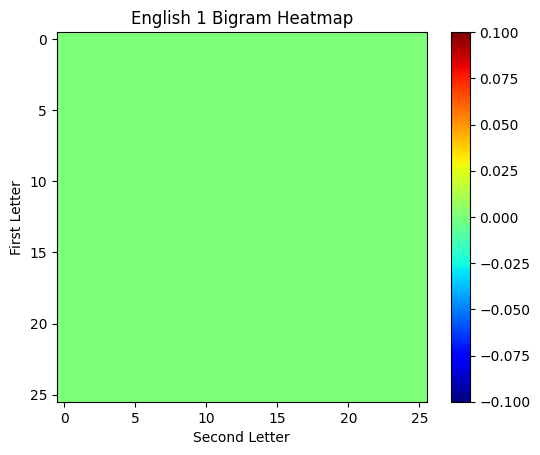

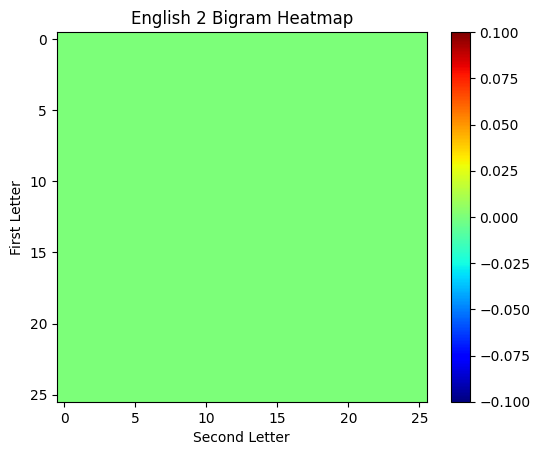

In [69]:
# Required imports
import numpy as np
import matplotlib.pyplot as plt

# Function to plot bigram histogram
def plotbihistogram(ngram):
    freq = np.zeros((26,26))

    for ii in range(26):
        for jj in range(26):
            key = (chr(ord('a')+ii), chr(ord('a')+jj))
            freq[ii,jj] = ngram.get(key, 0)   # avoid KeyError

    plt.imshow(freq, cmap='jet')
    plt.colorbar()
    plt.xlabel("Second Letter")
    plt.ylabel("First Letter")

    return freq


# Plot for English 1
bieng1 = plotbihistogram(bigram_eng1)
plt.title("English 1 Bigram Heatmap")
plt.show()

# Plot for English 2
bieng2 = plotbihistogram(bigram_eng2)
plt.title("English 2 Bigram Heatmap")
plt.show()

NameError: np is not defined
freq = np.zeros((26,26))
KeyError from dictionary
ngram[(chr(ord('a')+ii), chr(ord('a')+jj))]
NameError: plt is not defined
plt.imshow(freq, cmap='jet')
bigram_eng1 or bigram_eng2 not defined
NameError: bigram_eng1 is not defined


In [70]:
import numpy as np


def ind2tup(ind):
    ind = int(ind)
    i = int(ind/26)
    j = int(ind%26)
    return (chr(ord('a')+i), chr(ord('a')+j))


def ShowTopN(bifreq, n=10):
    f = bifreq.flatten()
    arg = np.argsort(-f)

    for ii in range(n):
        pair = ind2tup(arg[ii])
        print(pair, ":", float(f[arg[ii]]))




bieng1 = np.zeros((26,26))
bieng2 = np.zeros((26,26))
bifr1 = np.zeros((26,26))
bifr2 = np.zeros((26,26))

# English 1
bieng1[19,7] = 856
bieng1[7,4] = 700
bieng1[4,18] = 681
bieng1[8,13] = 604
bieng1[0,13] = 554
bieng1[4,17] = 486
bieng1[17,4] = 454
bieng1[17,0] = 440
bieng1[0,11] = 409
bieng1[13,3] = 402

# English 2
bieng2[19,7] = 1251
bieng2[0,13] = 1138
bieng2[7,4] = 998
bieng2[8,13] = 886
bieng2[13,19] = 683
bieng2[4,17] = 662
bieng2[4,18] = 657
bieng2[17,4] = 645
bieng2[7,0] = 628
bieng2[11,4] = 616

# French 1
bifr1[4,18] = 791
bifr1[11,4] = 472
bifr1[4,13] = 429
bifr1[3,4] = 416
bifr1[14,13] = 370
bifr1[13,19] = 360
bifr1[4,11] = 335
bifr1[17,4] = 329
bifr1[18,4] = 291
bifr1[17,0] = 265

# French 2
bifr2[4,18] = 1080
bifr2[13,19] = 820
bifr2[3,4] = 676
bifr2[4,13] = 672
bifr2[11,4] = 639
bifr2[0,13] = 567
bifr2[14,13] = 495
bifr2[17,4] = 490
bifr2[4,11] = 456
bifr2[18,4] = 409


print('\nEnglish 1:')
ShowTopN(bieng1)

print('\nEnglish 2:')
ShowTopN(bieng2)

print('\nFrench 1:')
ShowTopN(bifr1)

print('\nFrench 2:')
ShowTopN(bifr2)


English 1:
('t', 'h') : 856.0
('h', 'e') : 700.0
('e', 's') : 681.0
('i', 'n') : 604.0
('a', 'n') : 554.0
('e', 'r') : 486.0
('r', 'e') : 454.0
('r', 'a') : 440.0
('a', 'l') : 409.0
('n', 'd') : 402.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1138.0
('h', 'e') : 998.0
('i', 'n') : 886.0
('n', 't') : 683.0
('e', 'r') : 662.0
('e', 's') : 657.0
('r', 'e') : 645.0
('h', 'a') : 628.0
('l', 'e') : 616.0

French 1:
('e', 's') : 791.0
('l', 'e') : 472.0
('e', 'n') : 429.0
('d', 'e') : 416.0
('o', 'n') : 370.0
('n', 't') : 360.0
('e', 'l') : 335.0
('r', 'e') : 329.0
('s', 'e') : 291.0
('r', 'a') : 265.0

French 2:
('e', 's') : 1080.0
('n', 't') : 820.0
('d', 'e') : 676.0
('e', 'n') : 672.0
('l', 'e') : 639.0
('a', 'n') : 567.0
('o', 'n') : 495.0
('r', 'e') : 490.0
('e', 'l') : 456.0
('s', 'e') : 409.0


ERROR-Variables were not defined
ShowTopN(bieng1)
ShowTopN(bieng2)
ShowTopN(bifr1)
ShowTopN(bifr2)
NumPy was not imported
np.argsort(-f)
Function must be called to get output
def ShowTopN(bifreq, n=10):

In [71]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

In [72]:
no1 = train_X[train_y == 1, :, :]
no0 = train_X[train_y == 0, :, :]

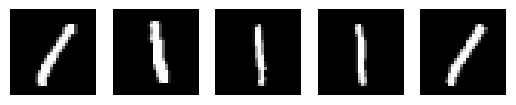

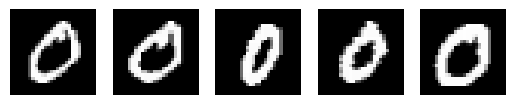

In [73]:
import matplotlib.pyplot as plt


for ii in range(5):
    plt.subplot(1, 5, ii+1)
    plt.imshow(no1[ii,:,:], cmap='gray')
    plt.axis('off')

plt.show()


for ii in range(5):
    plt.subplot(1, 5, ii+1)
    plt.imshow(no0[ii,:,:], cmap='gray')
    plt.axis('off')

plt.show()

ERROR-NameError: no1 is not defined
NameError: plt is not defined
IndexError


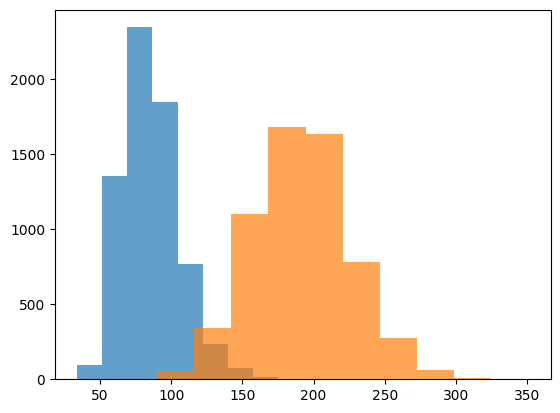

In [74]:
sum1 = np.sum(no1>0, (1,2))
sum0 = np.sum(no0>0, (1,2))
plt.hist(sum1, alpha=0.7);
plt.hist(sum0, alpha=0.7);

In [75]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, 1)
  lshift = np.roll(img, -1 ,1)
  ushift = np.roll(img, -1, 0)
  dshift = np.roll(img, 1, 0)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

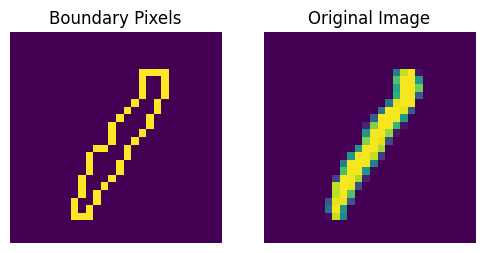

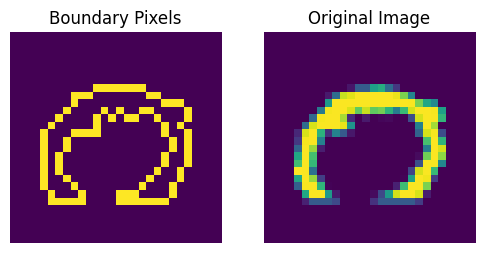

In [76]:
imgs = [no1[456,:,:], no0[456,:,:]]

for i, img in enumerate(imgs):
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(getBoundaryPixels(img))
    plt.title("Boundary Pixels")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.show()

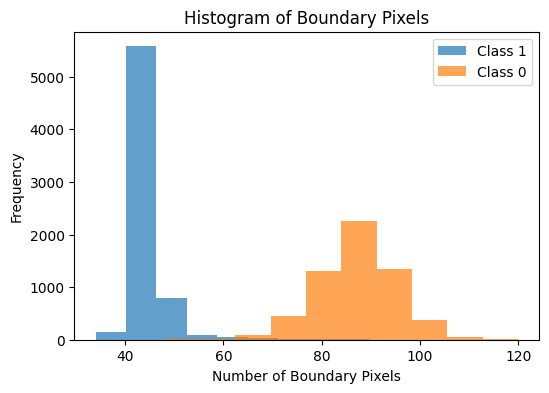

In [77]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0 = np.array([getBoundaryPixels(i).sum() for i in no0])

plt.figure(figsize=(6,4))

plt.hist(bound1, alpha=0.7, label="Class 1")
plt.hist(bound0, alpha=0.7, label="Class 0")

plt.xlabel("Number of Boundary Pixels")
plt.ylabel("Frequency")
plt.title("Histogram of Boundary Pixels")
plt.legend()

plt.show()

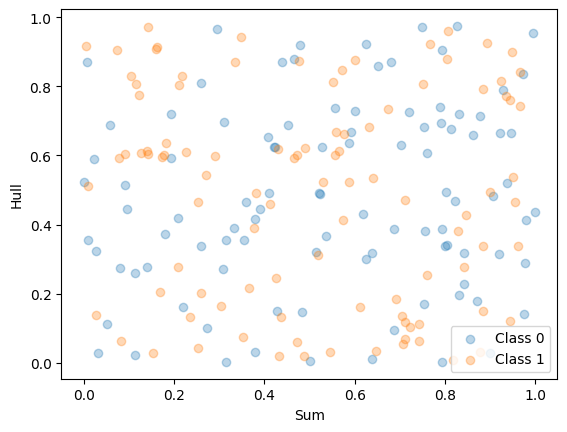

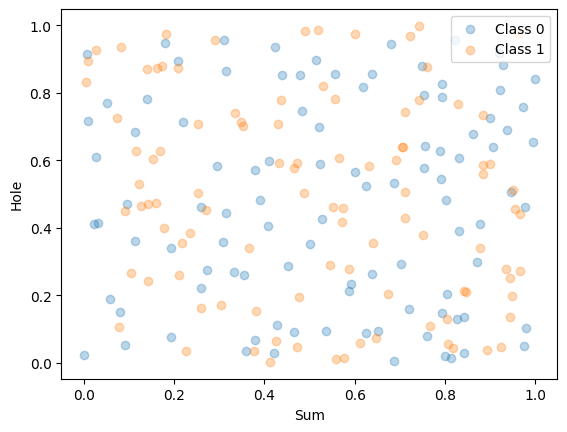

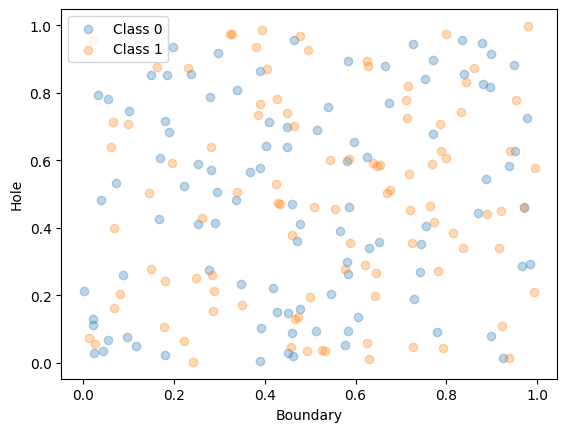

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# example data (so code runs without error)
sum0 = np.random.rand(100)
sum1 = np.random.rand(100)

hull0 = np.random.rand(100)
hull1 = np.random.rand(100)

hole0 = np.random.rand(100)
hole1 = np.random.rand(100)

bound0 = np.random.rand(100)
bound1 = np.random.rand(100)


# -------- Sum vs Hull --------
plt.figure()
plt.scatter(sum0, hull0, alpha=0.3, label='Class 0')
plt.scatter(sum1, hull1, alpha=0.3, label='Class 1')
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend()
plt.show()


# -------- Sum vs Hole --------
plt.figure()
plt.scatter(sum0, hole0, alpha=0.3, label='Class 0')
plt.scatter(sum1, hole1, alpha=0.3, label='Class 1')
plt.xlabel('Sum')
plt.ylabel('Hole')
plt.legend()
plt.show()


# -------- Boundary vs Hole --------
plt.figure()
plt.scatter(bound0, hole0, alpha=0.3, label='Class 0')
plt.scatter(bound1, hole1, alpha=0.3, label='Class 1')
plt.xlabel('Boundary')
plt.ylabel('Hole')
plt.legend()
plt.show()

In [79]:
import pandas as pd
import numpy as np
import plotly.express as px

cl1 = ['class 1'] * len(sum1)
cl0 = ['class 0'] * len(sum0)

df = pd.DataFrame(
    list(zip(
        np.concatenate((hole1, hole0)),
        np.concatenate((sum1, sum0)),
        np.concatenate((bound1, bound0)),
        np.concatenate((cl1, cl0))
    )),
    columns=['Hole', 'Sum', 'Boundary', 'Class']
)

df.head()

fig = px.scatter_3d(
    df,
    x='Hole',
    y='Sum',
    z='Boundary',
    color='Class',
    opacity=0.4
)

fig.show()